# **Optimización de modelos**

**Métodos basados en mallas:**

Búsqueda en Cuadrícula (Grid Search): se especifica un conjunto predefinido de valores para cada hiperparámetro que se desea ajustar.

Búsqueda Aleatoria (Random Search): En lugar de probar todas las combinaciones posibles como en la búsqueda en cuadrícula, se buscan combinaciones aleatorias.

**Métodos probabilísticos:**

Optimización Bayesiana: Utiliza métodos de optimización bayesiana para encontrar de manera eficiente las mejores configuraciones de hiperparámetros  ("Bayesian Optimization" y "Optuna“)

**Métodos de aprendizaje basado en poblaciones:**

Optimización Evolutiva: Se inspira en conceptos de la evolución biológica.


# **Optimización de modelos**

**Métodos basados en mallas:**

Búsqueda en Cuadrícula (Grid Search): se especifica un conjunto predefinido de valores para cada hiperparámetro que se desea ajustar.

Búsqueda Aleatoria (Random Search): En lugar de probar todas las combinaciones posibles como en la búsqueda en cuadrícula, se buscan combinaciones aleatorias.


**Métodos de aprendizaje basado en poblaciones:**

Optimización Evolutiva: Se inspira en conceptos de la evolución biológica.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#Cargamos los datos
data = pd.read_csv("videojuegos.csv")
data.head()


,videojuego,Edad,Sexo,Plataforma,Consumidor_habitual,Presupuesto para invertir
0,'Mass Effect',29,Mujer,PC,True,200
1,'Sim City',27,Mujer,Otros,True,600
2,'Dead Space',22,Hombre,'Xbox',False,200
3,'Battlefield',28,Mujer,'Xbox',True,370
4,'KOA: Reckoning',30,Mujer,PC,True,100


In [ ]:
#Hacer profiling de los datos


In [ ]:
#Creamos variables dummy para convertir  las categorías a números
data = pd.get_dummies(data, columns=['videojuego', 'Plataforma'], drop_first=False, dtype=int)
data = pd.get_dummies(data, columns=['Sexo', 'Consumidor_habitual'], drop_first=True, dtype=int)
data.head()

,Edad,Presupuesto para invertir,videojuego_'Battlefield',videojuego_'Crysis',videojuego_'Dead Space',videojuego_'F1',videojuego_'Fifa',videojuego_'KOA: Reckoning',videojuego_'Mass Effect',videojuego_'Sim City',Plataforma_'Play Station',Plataforma_'Xbox',Plataforma_Otros,Plataforma_PC,Sexo_Mujer,Consumidor_habitual_True
0,29,200,0,0,0,0,0,0,1,0,0,0,0,1,1,1
1,27,600,0,0,0,0,0,0,0,1,0,0,1,0,1,1
2,22,200,0,0,1,0,0,0,0,0,0,1,0,0,0,0
3,28,370,1,0,0,0,0,0,0,0,0,1,0,0,1,1
4,30,100,0,0,0,0,0,1,0,0,0,0,0,1,1,1


<Axes: >

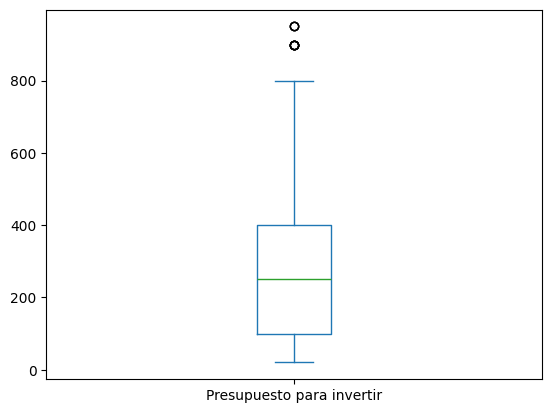

In [ ]:
#División 70-30
from sklearn.model_selection import train_test_split
X = data.drop("Presupuesto para invertir", axis = 1) # Variables predictoras
Y = data['Presupuesto para invertir'] #Variable objetivo
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3)
Y_train.plot(kind='box')

In [ ]:
#Dataframe para comparar los resultados
from sklearn import metrics
medidas= pd.DataFrame(index=['mse','rmse','mae','mape','max'])

In [ ]:
# Configuración manual de un modelo RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, max_depth=50, min_samples_leaf=2, max_samples=0.7, random_state=42)
model.fit(X_train, Y_train)


RandomForestRegressor(max_depth=50, max_samples=0.7, min_samples_leaf=2,
                      random_state=42)

      Random Forest
mse    69288.194268
rmse     263.226508
mae      133.247737
mape       0.342461
max      841.783214


/tmp/ipykernel_1380/487168386.py:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


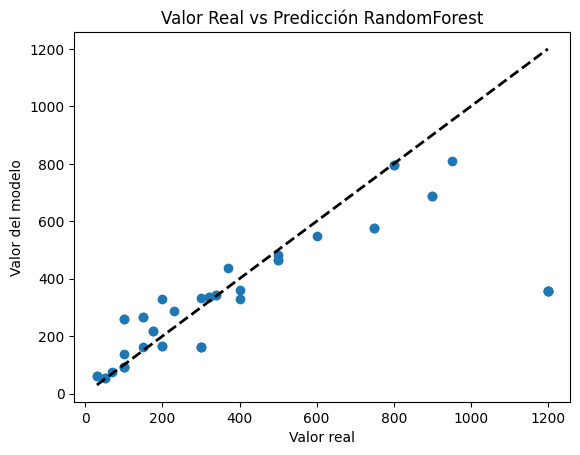

In [ ]:
# Evaluación en el conjunto de prueba

Y_pred = model.predict(X_test) #30%


mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['Random Forest']=[mse, rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción RandomForest')
plt.show() # Mostrar la grafica luego de que ya se definio todos los elementos

# **GRID SEARCH**

# **Random Search**

# **Bayes Search**

Maximiza el scoring

https://scikit-optimize.github.io/stable/modules/generated/skopt.BayesSearchCV.html


In [ ]:
!pip install scikit-optimize

# **Algoritmes Genéticos**

https://sklearn-genetic-opt.readthedocs.io/en/stable/api/gasearchcv.html


In [ ]:
!pip install sklearn-genetic-opt


# Se entrena mejor modelo con todos los datos

In [ ]:
# Se entrena la mejor configuración con todos los datos
genetics_best_model.fit(X,Y)

In [ ]:
# Se guarda el modelo para despliegue

